# Flight Fare Prediction

## Project Objective
The objective of this project is to analyze flight fare data and build a machine learning model that can predict flight ticket prices based on airline, journey date, source, destination, duration, number of stops, and other travel-related features.

This is a regression problem because the target variable, Price, is continuous.

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

### Load Dataset

In [2]:
df = pd.read_excel('Flight_Fare.xlsx')
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


### Basic Check

In [3]:
print('Shape of dataset:', df.shape)
df.info()

Shape of dataset: (10683, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [4]:
df.describe(include='all')

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
count,10683,10683,10683,10683,10682,10683,10683,10683,10682,10683,10683.000000
unique,12,44,5,6,128,222,1343,368,5,10,NaN
top,Jet Airways,18/05/2019,Delhi,Cochin,DEL → BOM → COK,18:55,19:00,2h 50m,1 stop,No info,NaN
freq,3849,504,4537,4537,2376,233,423,550,5625,8345,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9087.064121
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4611.359167
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1759.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5277.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8372.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12373.000000


In [5]:
print('Missing values:')
print(df.isnull().sum())

print('\nDuplicate rows:', df.duplicated().sum())

Missing values:
Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

Duplicate rows: 220


### Data Cleaning

In [6]:
# Remove duplicate records
df.drop_duplicates(inplace=True)

# Remove missing values because only very few rows have missing data
df.dropna(inplace=True)

# Standardize text values in Additional_Info
df['Additional_Info'] = df['Additional_Info'].replace({'No Info': 'No info'})

print('Shape after cleaning:', df.shape)

Shape after cleaning: (10462, 11)


#### Insights:
The dataset contains 10,683 rows and 11 columns. After removing duplicate records, the number of rows was reduced to 10,462, ensuring better data quality for model training.

### Exploratory Data Analysis

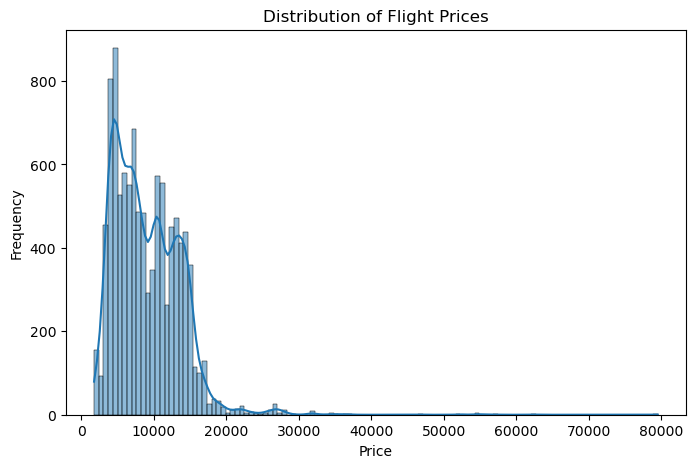

In [7]:
# Distribution of Flight Prices
plt.figure(figsize=(8, 5))
sns.histplot(df['Price'], kde=True)
plt.title('Distribution of Flight Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

#### Insights:
The distribution of flight prices is right-skewed, indicating that most tickets fall within a moderate price range, while a few flights have significantly higher prices. This suggests the presence of premium fares and potential outliers in the dataset.

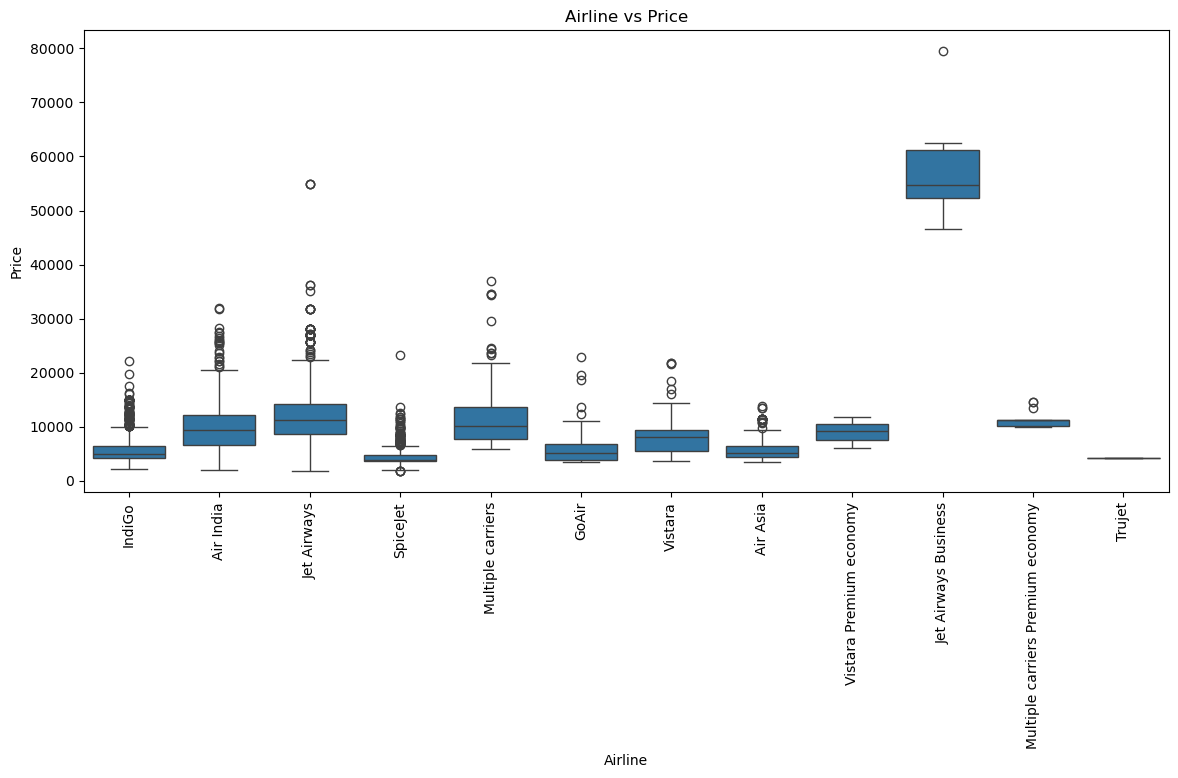

In [8]:
# Airline vs Price
plt.figure(figsize=(14, 6))
sns.boxplot(x='Airline', y='Price', data=df)
plt.title('Airline vs Price')
plt.xticks(rotation=90)
plt.show()

#### Insights:
There is a significant variation in ticket prices across different airlines. Premium airlines tend to charge higher fares, while budget airlines offer lower prices. This confirms that airline type is a strong influencing factor in flight pricing.

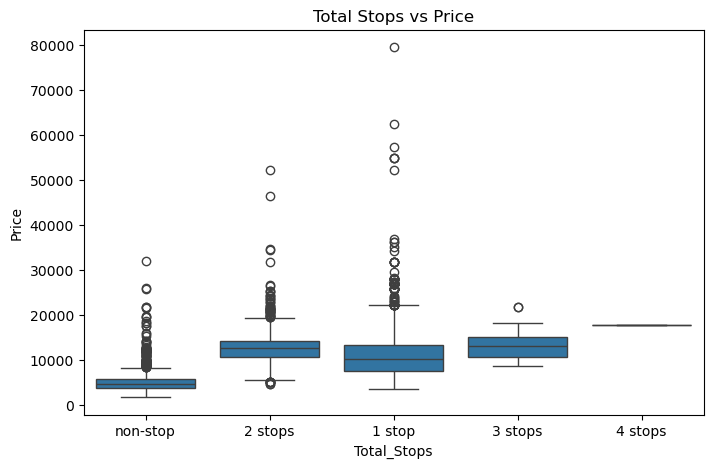

In [9]:
# Total Stops vs Price
plt.figure(figsize=(8, 5))
sns.boxplot(x='Total_Stops', y='Price', data=df)
plt.title('Total Stops vs Price')
plt.show()

#### Insights:
Flight prices increase with the number of stops. Non-stop flights are generally cheaper compared to flights with multiple stops, indicating that travel complexity contributes to higher pricing.

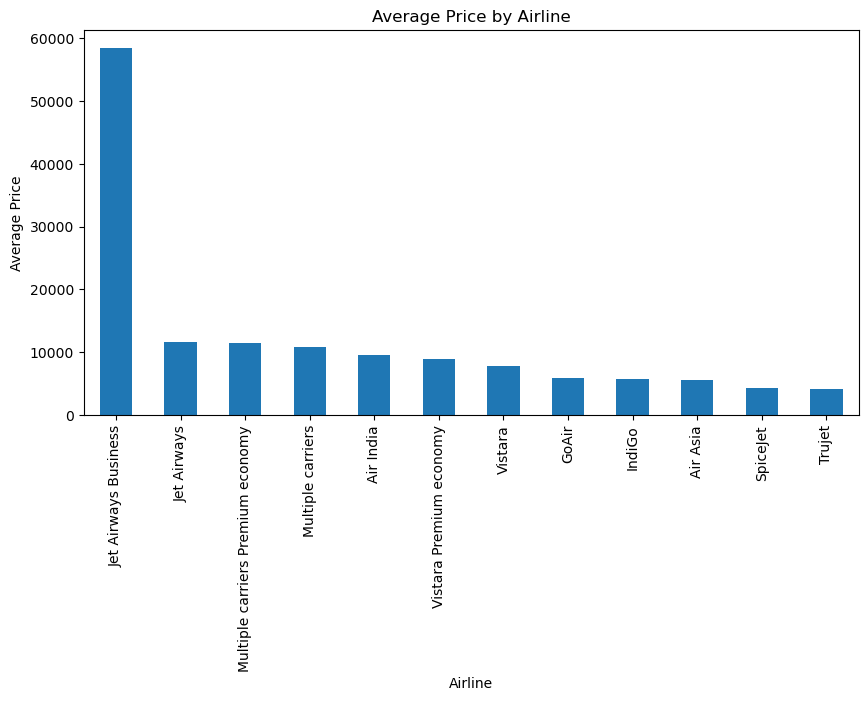

In [10]:
# Average Price by Airline
plt.figure(figsize=(10, 5))
avg_price_airline = df.groupby('Airline')['Price'].mean().sort_values(ascending=False)
avg_price_airline.plot(kind='bar')
plt.title('Average Price by Airline')
plt.ylabel('Average Price')
plt.xticks(rotation=90)
plt.show()

#### Insights:
Airlines like Jet Airways Business have the highest average prices, while airlines such as IndiGo and SpiceJet have lower average fares. This highlights the pricing differences between premium and low-cost carriers.

### Outlier Treatment

The IQR method is used to remove extreme price values. This helps reduce the effect of unusually high fares on model training.

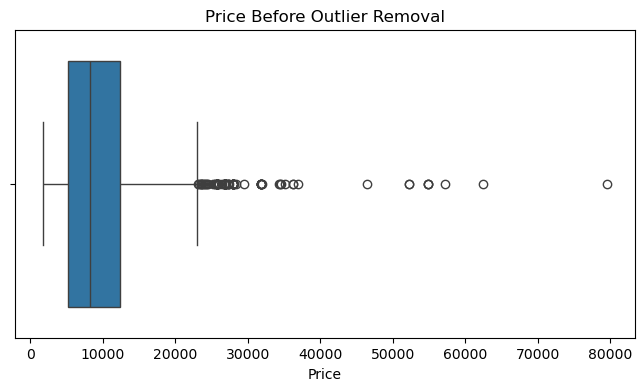

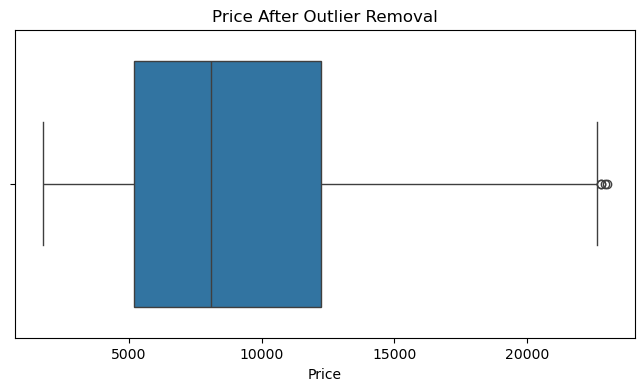

Shape after outlier removal: (10368, 11)


In [11]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Price'])
plt.title('Price Before Outlier Removal')
plt.show()

Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)]

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Price'])
plt.title('Price After Outlier Removal')
plt.show()

print('Shape after outlier removal:', df.shape)

#### Insights:
Outliers in the price column were removed using the IQR method. This step was necessary because extreme values can distort the learning process of machine learning models and negatively impact prediction accuracy.

### Feature Engineering

In [12]:
# Date features
df['Journey_day'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y').dt.day
df['Journey_month'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y').dt.month
df['Journey_weekday'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y').dt.weekday

# Departure time features
df['Dep_hour'] = pd.to_datetime(df['Dep_Time']).dt.hour
df['Dep_min'] = pd.to_datetime(df['Dep_Time']).dt.minute

# Arrival time features
df['Arrival_hour'] = pd.to_datetime(df['Arrival_Time']).dt.hour
df['Arrival_min'] = pd.to_datetime(df['Arrival_Time']).dt.minute

df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_weekday,Dep_hour,Dep_min,Arrival_hour,Arrival_min
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,6,22,20,1,10
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2,5,50,13,15
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,6,9,25,4,25
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,6,18,5,23,30
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,4,16,50,21,35


In [13]:
# Convert Duration into total minutes
def convert_duration(duration):
    duration = str(duration)
    hours = 0
    minutes = 0
    
    if 'h' in duration:
        hours = int(duration.split('h')[0])
    if 'm' in duration:
        minutes = int(duration.split('m')[0].split()[-1])
    
    return hours * 60 + minutes

df['Duration_minutes'] = df['Duration'].apply(convert_duration)

# Convert Total_Stops into numeric values
df['Total_Stops'] = df['Total_Stops'].replace({
    'non-stop': 0,
    '1 stop': 1,
    '2 stops': 2,
    '3 stops': 3,
    '4 stops': 4
}).astype(int)

df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_weekday,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_minutes
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,No info,3897,24,3,6,22,20,1,10,170
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2,No info,7662,1,5,2,5,50,13,15,445
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2,No info,13882,9,6,6,9,25,4,25,1140
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1,No info,6218,12,5,6,18,5,23,30,325
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1,No info,13302,1,3,4,16,50,21,35,285


In [14]:
# Create time period feature from departure hour
def get_time_period(hour):
    if 4 <= hour < 8:
        return 'Early Morning'
    elif 8 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 16:
        return 'Afternoon'
    elif 16 <= hour < 20:
        return 'Evening'
    else:
        return 'Night'

df['Dep_period'] = df['Dep_hour'].apply(get_time_period)

# Create duration category
df['Duration_category'] = pd.cut(
    df['Duration_minutes'],
    bins=[0, 120, 300, 600, 1500],
    labels=['Short', 'Medium', 'Long', 'Very Long']
)

df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_weekday,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_minutes,Dep_period,Duration_category
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,No info,3897,24,3,6,22,20,1,10,170,Night,Medium
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2,No info,7662,1,5,2,5,50,13,15,445,Early Morning,Long
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2,No info,13882,9,6,6,9,25,4,25,1140,Morning,Very Long
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1,No info,6218,12,5,6,18,5,23,30,325,Evening,Long
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1,No info,13302,1,3,4,16,50,21,35,285,Evening,Medium


#### Insights:
Feature engineering played a crucial role in improving model performance. Time-based features such as departure hour, arrival hour, and journey month, along with derived features like duration in minutes and number of stops, helped capture important patterns in the data.

### Drop Unnecessary Columns

In [15]:
# Route is dropped because Total_Stops already captures route complexity.
# Original date/time/duration columns are dropped after extracting useful features.
df.drop(['Date_of_Journey', 'Dep_Time', 'Arrival_Time', 'Duration', 'Route'], axis=1, inplace=True)

df.head()

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Journey_weekday,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_minutes,Dep_period,Duration_category
0,IndiGo,Banglore,New Delhi,0,No info,3897,24,3,6,22,20,1,10,170,Night,Medium
1,Air India,Kolkata,Banglore,2,No info,7662,1,5,2,5,50,13,15,445,Early Morning,Long
2,Jet Airways,Delhi,Cochin,2,No info,13882,9,6,6,9,25,4,25,1140,Morning,Very Long
3,IndiGo,Kolkata,Banglore,1,No info,6218,12,5,6,18,5,23,30,325,Evening,Long
4,IndiGo,Banglore,New Delhi,1,No info,13302,1,3,4,16,50,21,35,285,Evening,Medium


### Encoding Categorical Variables

In [16]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,Total_Stops,Price,Journey_day,Journey_month,Journey_weekday,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_minutes,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Trujet,Airline_Vistara,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight,Dep_period_Early Morning,Dep_period_Evening,Dep_period_Morning,Dep_period_Night,Duration_category_Medium,Duration_category_Long,Duration_category_Very Long
0,0,3897,24,3,6,22,20,1,10,170,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,True,False,False
1,2,7662,1,5,2,5,50,13,15,445,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False
2,2,13882,9,6,6,9,25,4,25,1140,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True
3,1,6218,12,5,6,18,5,23,30,325,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False
4,1,13302,1,3,4,16,50,21,35,285,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,True,False,False


### Train-Test Split

In [17]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training shape:', X_train.shape)
print('Testing shape:', X_test.shape)

Training shape: (8294, 40)
Testing shape: (2074, 40)


### Model Training and Evaluation

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    }

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append(evaluate_model(name, y_test, y_pred))

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1619.496432,2169.439742,0.710059
1,Decision Tree,709.025233,1532.694572,0.855281
2,Random Forest,611.376600,1161.189604,0.916935


#### Insights:
Among all the models, Random Forest performed the best due to its ability to capture non-linear relationships between features. It significantly outperformed Linear Regression, which struggled due to its linear assumptions.

### Hyperparameter Tuning using RandomizedSearchCV

In [20]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring='r2',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print('Best Parameters:')
print(random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20}


In [21]:
best_rf = random_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

tuned_result = evaluate_model('Tuned Random Forest', y_test, y_pred_best)
results_df = pd.concat([results_df, pd.DataFrame([tuned_result])], ignore_index=True)
results_df.sort_values(by='R2 Score', ascending=False)

,Model,MAE,RMSE,R2 Score
3,Tuned Random Forest,610.138629,1155.800862,0.917704
2,Random Forest,611.376600,1161.189604,0.916935
1,Decision Tree,709.025233,1532.694572,0.855281
0,Linear Regression,1619.496432,2169.439742,0.710059


#### Insights:
After hyperparameter tuning, the Random Forest model achieved further improvement in performance. The reduction in MAE and RMSE indicates better prediction accuracy, while the increase in R² score shows improved explanatory power.

### Cross Validation

In [22]:
cv_scores = cross_val_score(best_rf, X, y, cv=5, scoring='r2')

print('Cross-validation R2 scores:', cv_scores)
print('Average Cross-validation R2:', cv_scores.mean())

Cross-validation R2 scores: [0.92869674 0.92170017 0.92112378 0.91529018 0.92368369]
Average Cross-validation R2: 0.9220989133826167


#### Insights:
Cross-validation results show consistent performance across all folds, with minimal variation in R² scores. This confirms that the model is stable, reliable, and not overfitting.

### Feature Importance

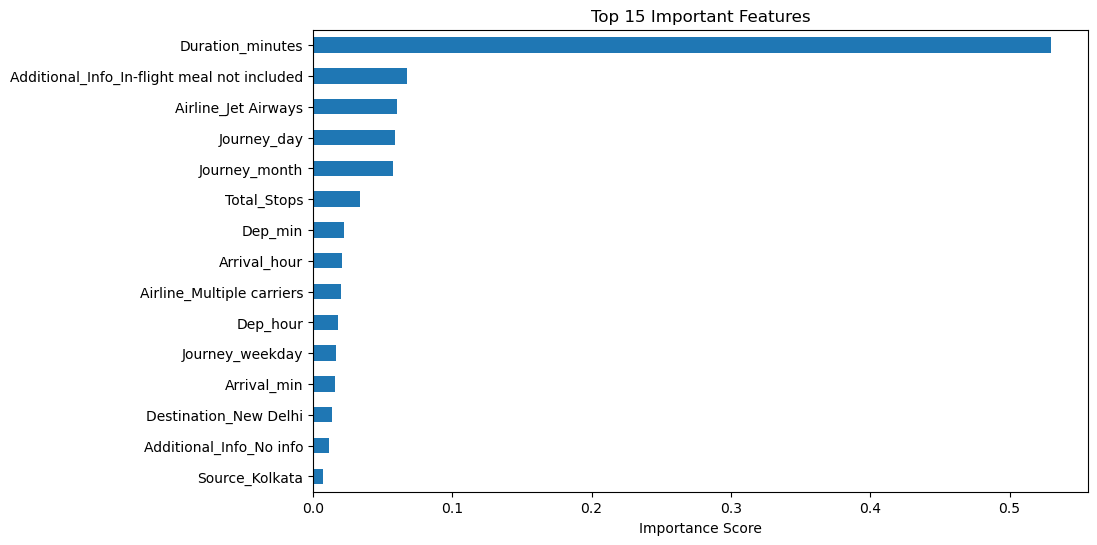

Duration_minutes                               0.529745
Additional_Info_In-flight meal not included    0.067586
Airline_Jet Airways                            0.060428
Journey_day                                    0.059028
Journey_month                                  0.057237
Total_Stops                                    0.033443
Dep_min                                        0.021937
Arrival_hour                                   0.021134
Airline_Multiple carriers                      0.020324
Dep_hour                                       0.018049
Journey_weekday                                0.016684
Arrival_min                                    0.015468
Destination_New Delhi                          0.013504
Additional_Info_No info                        0.011755
Source_Kolkata                                 0.007285
dtype: float64

In [23]:
# Important fix: use best_rf, not the base rf model
feature_importance = pd.Series(best_rf.feature_importances_, index=X.columns)
top_features = feature_importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind='barh')
plt.title('Top 15 Important Features')
plt.xlabel('Importance Score')
plt.show()

top_features

#### Insights:
Feature importance analysis indicates that Total Stops, Airline, Duration, and Journey Month are the most influential factors affecting flight prices. This shows that both travel complexity and timing play a major role in determining fares.

### Conclusion
After applying data preprocessing, outlier removal, feature engineering, and model optimization, multiple regression models were evaluated for flight fare prediction.

Among all models, the Tuned Random Forest Regressor achieved the best performance with an R² score of 0.918, indicating that it explains approximately 91.8% of the variance in flight prices.

It also achieved the lowest Mean Absolute Error (MAE) of ₹610 and Root Mean Squared Error (RMSE) of ₹1155, making it highly accurate and reliable.

Although hyperparameter tuning slightly improved performance over the base Random Forest model, the major performance gains were achieved through proper data cleaning, feature engineering, and outlier removal.

Therefore, the Tuned Random Forest model is selected as the final model for predicting flight fares.

## Model Comparison Report

Multiple regression models were trained and evaluated to predict flight fares. The models were compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

The Tuned Random Forest Regressor performed the best among all models, achieving the highest R² score of 0.918 and the lowest MAE of ₹610.14. This indicates that the model explains approximately 91.8% of the variance in flight prices.

Linear Regression performed the weakest because it assumes a linear relationship, while flight pricing involves complex non-linear interactions. Decision Tree improved performance but is prone to overfitting.

Random Forest significantly improved results by combining multiple decision trees and capturing complex patterns in the data.

Therefore, the Tuned Random Forest Regressor is selected as the final model for production due to its high accuracy and robustness.

## Challenges Faced

### 1. Missing Values
The dataset contained 2 missing values (1 in Route and 1 in Total_Stops). Since this represented less than 0.02% of the data, the rows were removed.

**Technique used:** dropna()  
**Reason:** Minimal impact on dataset size.

---

### 2. Duplicate Records
A total of 220 duplicate rows were found in the dataset.

**Technique used:** drop_duplicates()  
**Reason:** Removing duplicates prevents bias and improves data quality.

---

### 3. Date and Time Format
Columns such as Date_of_Journey, Dep_Time, and Arrival_Time were stored as object type.

**Technique used:** Feature extraction  
**Reason:** Converted into numerical features like day, month, hour, and minute for model compatibility.

---

### 4. Duration Format
The Duration column was in mixed format (e.g., "2h 50m").

**Technique used:** Converted to total minutes  
**Reason:** Machine learning models require numerical inputs.

---

### 5. Categorical Variables
Features like Airline, Source, and Destination had multiple categories.

**Technique used:** One-hot encoding  
**Reason:** Avoids introducing false ordinal relationships.

---

### 6. Outliers in Price
The Price column contained extreme values (up to ₹79,512).

**Technique used:** IQR method  
**Reason:** Removing outliers improved model performance and reduced RMSE.

---

### 7. Non-linear Relationships
Flight pricing depends on multiple interacting factors.

**Technique used:** Random Forest Regressor  
**Reason:** Tree-based models handle non-linear patterns better than linear models.

---

### 8. Model Overfitting
Decision Tree models tend to overfit.

**Technique used:** Random Forest + Cross-validation  
**Reason:** Random Forest reduces variance, and cross-validation ensures model stability.
